In [346]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [347]:
df = pd.read_csv("../data/fincaraiz_venta_bogota_20260803.csv")

In [348]:
initial_df = df.copy()

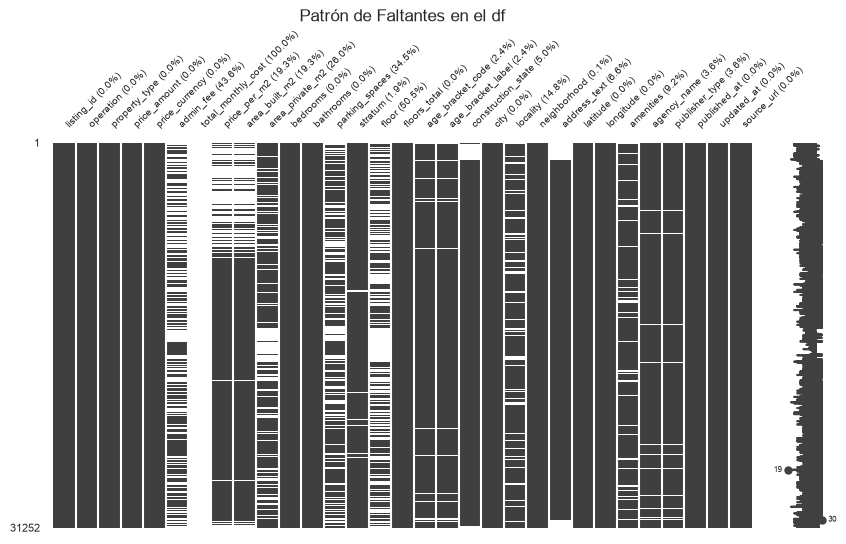

In [349]:
n_cols = len(df.columns)
ancho = max(10, int(n_cols * 0.35))
alto = 5

tamano_letra = max(6, 10 - n_cols // 10)

# Porcentaje de nulos por columna
pct_nulos = df.isnull().mean() * 100

try:
    ax = (
        msno.matrix(df, figsize=(ancho, alto), fontsize=tamano_letra)
        or plt.gca()
    )
    plt.title("Patrón de Faltantes en el df")

    if len(ax.get_xticks()) == n_cols:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(
            [f"{c} ({p:.1f}%)" for c, p in zip(df.columns, pct_nulos)],
            rotation=45,
            ha="left",
            fontsize=tamano_letra,
        )

    plt.show()

except Exception:
    plt.figure(figsize=(ancho, alto))
    missing_pattern = df.isnull()

    plt.imshow(missing_pattern.astype(int), aspect="auto", cmap="RdYlGn_r")

    plt.xticks(
        ticks=range(n_cols),
        labels=[
            f"{c} ({p:.1f}%)"
            for c, p in zip(missing_pattern.columns, pct_nulos)
        ],
        rotation=90,
        fontsize=tamano_letra,
        ha="center",
    )
    plt.yticks([])
    plt.title("Patrón de Faltantes (blanco = faltante)")
    plt.colorbar(label="1=Faltante, 0=Presente")

    plt.tight_layout()  # Evita que las etiquetas se corten abajo
    plt.show()

# Drop useless columns

In [350]:
df.columns

Index(['listing_id', 'operation', 'property_type', 'price_amount',
       'price_currency', 'admin_fee', 'total_monthly_cost', 'price_per_m2',
       'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
       'parking_spaces', 'stratum', 'floor', 'floors_total',
       'age_bracket_code', 'age_bracket_label', 'construction_state', 'city',
       'locality', 'neighborhood', 'address_text', 'latitude', 'longitude',
       'amenities', 'agency_name', 'publisher_type', 'published_at',
       'updated_at', 'source_url'],
      dtype='str')

In [351]:
useful_columns = [
    "listing_id",
    "operation",
    "source_url",
    "total_monthly_cost",
    "address_text",
]

df.drop(columns=useful_columns, inplace=True)

In [352]:
df.columns

Index(['property_type', 'price_amount', 'price_currency', 'admin_fee',
       'price_per_m2', 'area_built_m2', 'area_private_m2', 'bedrooms',
       'bathrooms', 'parking_spaces', 'stratum', 'floor', 'floors_total',
       'age_bracket_code', 'age_bracket_label', 'construction_state', 'city',
       'locality', 'neighborhood', 'latitude', 'longitude', 'amenities',
       'agency_name', 'publisher_type', 'published_at', 'updated_at'],
      dtype='str')

In [353]:
df[df["price_currency"] == "U$S"]
# there's a single row with a different currency, we will drop it.
# that row is full of NaN values, also is kinda weird that the price is in
# dollars but the property is in ciudad bolivar.
# by the way, the column price_currency is useless since all the other rows
# have the same value, so we will drop it too.

,property_type,price_amount,price_currency,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,...,city,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,published_at,updated_at
512,casa,190000000.0,U$S,NaN,NaN,NaN,216.0,8,3,NaN,...,Bogotá,Ciudad Bolivar,Compartir,4.556483,-74.146869,Baño Auxiliar|Colegios / Universidades|Instala...,NaN,NaN,2024-02-19,2026-07-22


In [354]:
df = df[df["price_currency"] != "U$S"]
df.drop(columns=["price_currency"], inplace=True)
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,city,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,published_at,updated_at
0,casa,880000000.0,736000.0,5500000.00,160.0,151.0,3,3,2.0,4.0,...,Bogotá,Suba,UB. Hacienda Cordoba Niza,4.711642,-74.062946,Alarma|Baño Auxiliar|Calentador|Canchas Deport...,NaN,NaN,2023-01-24,2026-06-16
1,casa,650000000.0,NaN,4237288.14,153.4,153.4,4,2,1.0,3.0,...,Bogotá,Barrios Unidos,Benjamin Herrera,4.655459,-74.073723,Baño Auxiliar|Colegios / Universidades|Estudio...,NaN,NaN,2023-01-31,2026-07-24
2,casa,625000000.0,643500.0,5208333.33,120.0,120.0,4,3,2.0,5.0,...,Bogotá,Usaquen,Lagos DE Torca,4.764007,-74.042742,Baño Auxiliar|Calentador|Cancha de Tennis|Canc...,NaN,NaN,2023-02-08,2026-06-18
3,oficina,830000000.0,1305000.0,9120879.12,91.0,91.0,1,1,2.0,6.0,...,Bogotá,NaN,Chicó Reservado,4.681917,-74.045349,Ascensor|Baños comunales|Cableado de Red|Circu...,NaN,NaN,2023-02-16,2026-07-19
4,apartamento,470000000.0,560000.0,8392857.14,56.0,58.0,1,2,1.0,4.0,...,Bogotá,Usaquen,Cedritos,4.721554,-74.036146,Ascensor|Barra estilo americano|Baño Auxiliar|...,NaN,NaN,2023-03-01,2026-07-21


# Drop comercial properties. 

since we are only interested in residential ones.

In [355]:
useful_properties = [
    "casa",
    "apartamento",
    "apartaestudio",
    "casa_campestre",
    "habitacion",
    "finca",
    "cabana",
]

In [356]:
df = df.loc[df["property_type"].isin(useful_properties)]

In [357]:
df.head()

,property_type,price_amount,admin_fee,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,...,city,locality,neighborhood,latitude,longitude,amenities,agency_name,publisher_type,published_at,updated_at
0,casa,8.800000e+08,736000.0,5500000.00,160.0,151.0,3,3,2.0,4.0,...,Bogotá,Suba,UB. Hacienda Cordoba Niza,4.711642,-74.062946,Alarma|Baño Auxiliar|Calentador|Canchas Deport...,NaN,NaN,2023-01-24,2026-06-16
1,casa,6.500000e+08,NaN,4237288.14,153.4,153.4,4,2,1.0,3.0,...,Bogotá,Barrios Unidos,Benjamin Herrera,4.655459,-74.073723,Baño Auxiliar|Colegios / Universidades|Estudio...,NaN,NaN,2023-01-31,2026-07-24
2,casa,6.250000e+08,643500.0,5208333.33,120.0,120.0,4,3,2.0,5.0,...,Bogotá,Usaquen,Lagos DE Torca,4.764007,-74.042742,Baño Auxiliar|Calentador|Cancha de Tennis|Canc...,NaN,NaN,2023-02-08,2026-06-18
4,apartamento,4.700000e+08,560000.0,8392857.14,56.0,58.0,1,2,1.0,4.0,...,Bogotá,Usaquen,Cedritos,4.721554,-74.036146,Ascensor|Barra estilo americano|Baño Auxiliar|...,NaN,NaN,2023-03-01,2026-07-21
5,casa,3.300000e+09,NaN,NaN,NaN,350.0,4,3,2.0,6.0,...,Bogotá,Suba,San Jose DE Bavaria,4.769128,-74.061616,Balcón|Barra estilo americano|Baño Auxiliar|Ch...,Dávila Peña y CIA SAS,inmobiliaria,2023-03-22,2026-06-13


## Reevaluate the missing data pattern after cleaning comercial properties

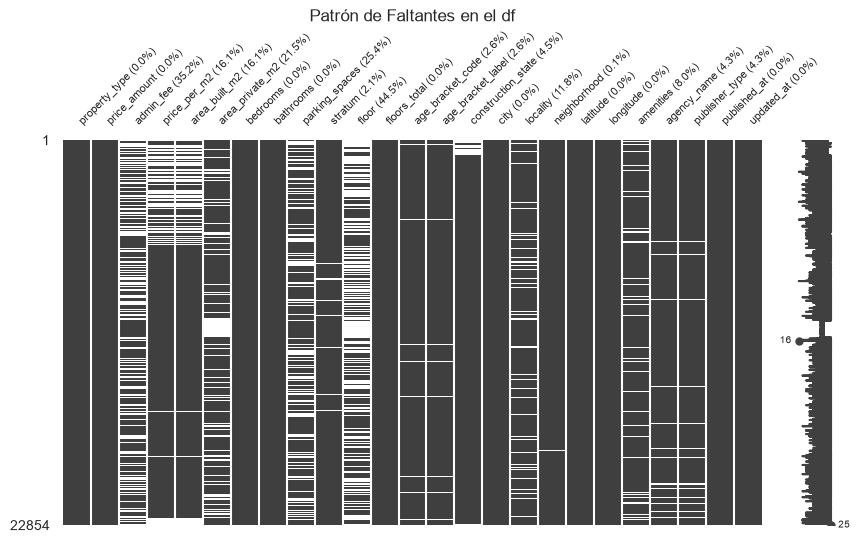

In [358]:
n_cols = len(df.columns)
ancho = max(10, int(n_cols * 0.35))
alto = 5

tamano_letra = max(6, 10 - n_cols // 10)

# Porcentaje de nulos por columna
pct_nulos = df.isnull().mean() * 100

try:
    ax = (
        msno.matrix(df, figsize=(ancho, alto), fontsize=tamano_letra)
        or plt.gca()
    )
    plt.title("Patrón de Faltantes en el df")

    if len(ax.get_xticks()) == n_cols:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(
            [f"{c} ({p:.1f}%)" for c, p in zip(df.columns, pct_nulos)],
            rotation=45,
            ha="left",
            fontsize=tamano_letra,
        )

    plt.show()

except Exception:
    plt.figure(figsize=(ancho, alto))
    missing_pattern = df.isnull()

    plt.imshow(missing_pattern.astype(int), aspect="auto", cmap="RdYlGn_r")

    plt.xticks(
        ticks=range(n_cols),
        labels=[
            f"{c} ({p:.1f}%)"
            for c, p in zip(missing_pattern.columns, pct_nulos)
        ],
        rotation=90,
        fontsize=tamano_letra,
        ha="center",
    )
    plt.yticks([])
    plt.title("Patrón de Faltantes (blanco = faltante)")
    plt.colorbar(label="1=Faltante, 0=Presente")

    plt.tight_layout()  # Evita que las etiquetas se corten abajo
    plt.show()

In [359]:
# 1. Row counts
len_initial = len(initial_df)
len_final = len(df)

# 2. Calculate null rates (%) relative to total rows in each DataFrame
initial_rate = (initial_df.isna().sum() / len_initial) * 100
final_rate = (df.isna().sum() / len_final) * 100

# 3. Combine into summary DataFrame
null_rate_summary = pd.DataFrame(
    {"Initial_Null_Rate (%)": initial_rate, "Final_Null_Rate (%)": final_rate}
)


null_rate_summary["Pct_Points_Reduced"] = (
    null_rate_summary["Initial_Null_Rate (%)"]
    - null_rate_summary["Final_Null_Rate (%)"]
)


null_rate_summary["Relative_Improvement (%)"] = np.where(
    null_rate_summary["Initial_Null_Rate (%)"] > 0,
    (
        null_rate_summary["Pct_Points_Reduced"]
        / null_rate_summary["Initial_Null_Rate (%)"]
    )
    * 100,
    0.0,
)


null_rate_summary = null_rate_summary.round(2)

print(f"Total Rows: Initial = {len_initial:,} | Final = {len_final:,}\n")
null_rate_summary

Total Rows: Initial = 31,252 | Final = 22,854



,Initial_Null_Rate (%),Final_Null_Rate (%),Pct_Points_Reduced,Relative_Improvement (%)
address_text,6.61,NaN,NaN,NaN
admin_fee,43.55,35.20,8.35,19.17
age_bracket_code,2.44,2.62,-0.18,-7.32
age_bracket_label,2.44,2.62,-0.18,-7.32
agency_name,3.57,4.29,-0.72,-20.19
amenities,9.20,8.00,1.20,13.01
area_built_m2,19.35,16.07,3.28,16.95
area_private_m2,25.99,21.52,4.47,17.19
bathrooms,0.00,0.00,0.00,0.00
bedrooms,0.00,0.00,0.00,0.00


in general, the null rates have decreased significantly, especially in columns that were dropped or filtered. The relative improvement column shows the percentage of the original null rate that has been eliminated through the cleaning process.

despite of that, there are some colums that increased their null rate: 

* `age_bracket_code` (-7.32)
* `age_bracket_label` (-7.32)
* `agency_name` (-20.19)
* `city` (-17.21) -> actually, this one is easy to fill, maybe it could also consider zipa or chia as cities.
* `neighborhood` (-4.57) -> it could be inputed using coordinates
* `publisher_type` (-20.19)
* `stratum` (-12.80) -> also will be imputed using coordinates and BBOX.



In [360]:
cols_with_nulls = [col for col in df.columns if df[col].isnull().any()]
cols_with_nulls

['admin_fee',
 'price_per_m2',
 'area_built_m2',
 'area_private_m2',
 'parking_spaces',
 'stratum',
 'floor',
 'age_bracket_code',
 'age_bracket_label',
 'construction_state',
 'city',
 'locality',
 'neighborhood',
 'amenities',
 'agency_name',
 'publisher_type']

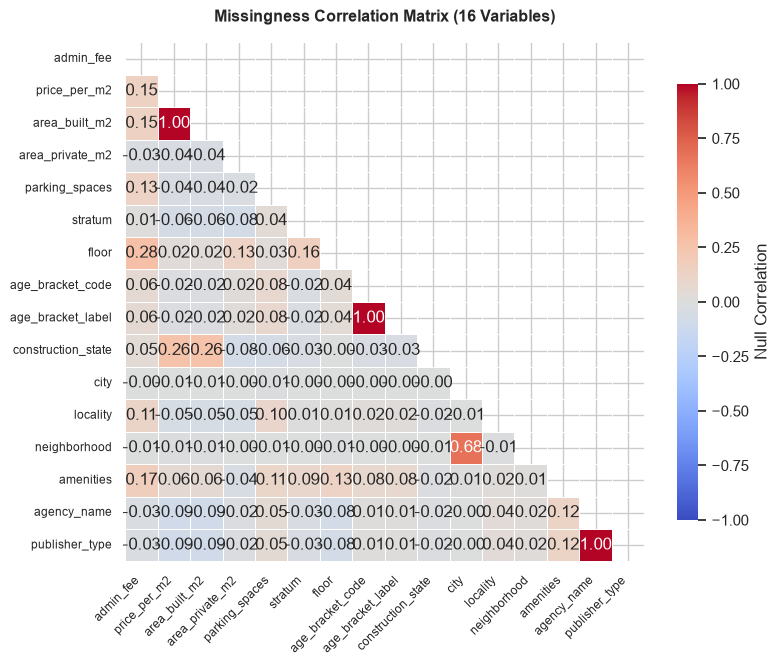

In [361]:
# 1. Extract missing indicators and remove constant/zero-variance columns
cols_with_nulls = [col for col in df.columns if df[col].isnull().sum() > 0]
missing_df = df[cols_with_nulls].isnull().astype(int)

# Drop columns with zero variance (e.g., 0% or 100% missing)
missing_df = missing_df.loc[:, missing_df.std() > 0]

# 2. Compute correlation matrix
missing_corr = missing_df.corr()
n_vars = missing_corr.shape[1]

# 3. Dynamic sizing & settings based on variable count
fig_size = max(7, n_vars * 0.5)
show_annot = n_vars <= 15  # Only annotate numbers if 15 or fewer variables
font_scale = max(6, min(10, 120 / n_vars))  # Scale label font size

plt.figure(figsize=(fig_size, fig_size * 0.85))

# Mask upper triangle + diagonal
mask = np.triu(np.ones_like(missing_corr, dtype=bool))

# 4. Plot heatmap
sns.heatmap(
    missing_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5 if n_vars <= 30 else 0,
    cbar_kws={"shrink": 0.8, "label": "Null Correlation"},
    annot_kws={"size": font_scale} if show_annot else None,
)

# 5. Format labels
plt.xticks(rotation=45, ha="right", fontsize=font_scale + 1)
plt.yticks(rotation=0, fontsize=font_scale + 1)
plt.title(
    f"Missingness Correlation Matrix ({n_vars} Variables)",
    fontsize=font_scale + 4,
    pad=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# Looking for MAR mechanisms

In [362]:
cols_with_nulls, df.columns

(['admin_fee',
  'price_per_m2',
  'area_built_m2',
  'area_private_m2',
  'parking_spaces',
  'stratum',
  'floor',
  'age_bracket_code',
  'age_bracket_label',
  'construction_state',
  'city',
  'locality',
  'neighborhood',
  'amenities',
  'agency_name',
  'publisher_type'],
 Index(['property_type', 'price_amount', 'admin_fee', 'price_per_m2',
        'area_built_m2', 'area_private_m2', 'bedrooms', 'bathrooms',
        'parking_spaces', 'stratum', 'floor', 'floors_total',
        'age_bracket_code', 'age_bracket_label', 'construction_state', 'city',
        'locality', 'neighborhood', 'latitude', 'longitude', 'amenities',
        'agency_name', 'publisher_type', 'published_at', 'updated_at'],
       dtype='str'))

In [363]:
df = df[df["property_type"] != "cabana"]  # since there's only one row with
# this property type, we will drop it.

### `admin_fee` vs `property_type`

In [364]:
def get_cramers_v_label(v: float) -> str:
    if v < 0.10:
        return "Negligible"
    elif v < 0.30:
        return "Small"
    elif v < 0.50:
        return "Medium"
    else:
        return "Large"


def get_cohens_d_label(d: float) -> str:
    abs_d = abs(d)
    if abs_d < 0.20:
        return "Negligible"
    elif abs_d < 0.50:
        return "Small"
    elif abs_d < 0.80:
        return "Medium"
    else:
        return "Large"


def analyze_missingness_mar(
    df: pd.DataFrame, target_col: str, cat_col: str, alpha: float = 0.05
) -> dict:
    is_missing = df[target_col].isnull()
    contingency_table = pd.crosstab(df[cat_col], is_missing)

    chi2, p_value, dof, _ = stats.chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    k = contingency_table.shape[0]

    # Cramér's V calculation
    denom = n * min(k - 1, 1)
    cramers_v = np.sqrt(chi2 / denom) if denom > 0 else 0.0

    return {
        "target_col (examined one)": target_col,
        "predictor_col": cat_col,
        "predictor_type": "Categorical",
        "stat_test": "Chi-Square",
        "statistic": chi2,
        "p_value": p_value,
        "is_mar": p_value < alpha,
        "effect_size": cramers_v,
        "effect_size_type": "Cramér's V",
        "effect_magnitude": get_cramers_v_label(cramers_v),
    }


def analyze_missingness_mar_continuous(
    df: pd.DataFrame, target_col: str, cont_col: str, alpha: float = 0.05
) -> dict:
    is_missing = df[target_col].isnull()
    vals_present = df.loc[~is_missing, cont_col].dropna()
    vals_missing = df.loc[is_missing, cont_col].dropna()

    stat, p_value = stats.mannwhitneyu(
        vals_present, vals_missing, alternative="two-sided"
    )

    # Cohen's d calculation
    n1, n2 = len(vals_present), len(vals_missing)
    s1, s2 = vals_present.std(), vals_missing.std()

    if n1 > 1 and n2 > 1:
        s_pooled = np.sqrt(
            ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
        )
        cohens_d = (
            (vals_present.mean() - vals_missing.mean()) / s_pooled
            if s_pooled > 0
            else 0.0
        )
    else:
        cohens_d = 0.0

    return {
        "target_col (examined one)": target_col,
        "predictor_col": cont_col,
        "predictor_type": "Continuous",
        "stat_test": "Mann-Whitney U",
        "statistic": stat,
        "p_value": p_value,
        "is_mar": p_value < alpha,
        "effect_size": abs(cohens_d),
        "effect_size_type": "Cohen's d",
        "effect_magnitude": get_cohens_d_label(cohens_d),
    }

In [365]:
df.info()

<class 'pandas.DataFrame'>
Index: 22853 entries, 0 to 31251
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       22853 non-null  str    
 1   price_amount        22853 non-null  float64
 2   admin_fee           14809 non-null  float64
 3   price_per_m2        19182 non-null  float64
 4   area_built_m2       19182 non-null  float64
 5   area_private_m2     17934 non-null  float64
 6   bedrooms            22853 non-null  int64  
 7   bathrooms           22853 non-null  int64  
 8   parking_spaces      17038 non-null  float64
 9   stratum             22363 non-null  float64
 10  floor               12682 non-null  float64
 11  floors_total        22853 non-null  int64  
 12  age_bracket_code    22255 non-null  float64
 13  age_bracket_label   22255 non-null  str    
 14  construction_state  21817 non-null  str    
 15  city                22847 non-null  str    
 16  locality            

In [366]:
results_list = []
alpha = 0.05

for col in cols_with_nulls:
    for sep_col in df.columns:
        if col == sep_col:
            continue
        if df[sep_col].isnull().sum() > 0:
            continue
        try:
            dtype = df[sep_col].dtype
            if dtype in ["object", "category", "bool", "str"]:
                res = analyze_missingness_mar(
                    df, target_col=col, cat_col=sep_col, alpha=alpha
                )
                results_list.append(res)
            elif dtype in ["int64", "float64", "int32", "float32"]:
                res = analyze_missingness_mar_continuous(
                    df, target_col=col, cont_col=sep_col, alpha=alpha
                )
                results_list.append(res)
        except Exception as e:
            print(f"Error analyzing '{col}' vs '{sep_col}': {e}")

# Build Master DataFrame
mar_results_df = pd.DataFrame(results_list)

# Sort by statistical significance and effect size
mar_results_df = mar_results_df.sort_values(
    by=["is_mar", "effect_size"], ascending=[False, False]
).reset_index(drop=True)

In [367]:
exclude_cols = ["amenities", "agency_name", "neighborhood"]

mar_results_df[
    (mar_results_df["is_mar"])
    & (mar_results_df["effect_magnitude"].isin(["Large", "Medium"]))
    & (~mar_results_df["predictor_col"].isin(exclude_cols))
]

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude
0,city,longitude,Continuous,Mann-Whitney U,2.284700e+04,4.684501e-03,True,91.276091,Cohen's d,Large
1,city,latitude,Continuous,Mann-Whitney U,1.142350e+05,4.684501e-03,True,7.648492,Cohen's d,Large
2,agency_name,floors_total,Continuous,Mann-Whitney U,4.280696e+06,0.000000e+00,True,1.256166,Cohen's d,Large
3,publisher_type,floors_total,Continuous,Mann-Whitney U,4.280696e+06,0.000000e+00,True,1.256166,Cohen's d,Large
4,construction_state,published_at,Categorical,Chi-Square,2.112011e+04,0.000000e+00,True,0.961339,Cramér's V,Large
5,admin_fee,bedrooms,Continuous,Mann-Whitney U,3.493021e+07,0.000000e+00,True,0.894131,Cohen's d,Large
6,parking_spaces,bathrooms,Continuous,Mann-Whitney U,7.782795e+07,0.000000e+00,True,0.801213,Cohen's d,Large
7,price_per_m2,published_at,Categorical,Chi-Square,1.314608e+04,0.000000e+00,True,0.758449,Cramér's V,Large
8,area_built_m2,published_at,Categorical,Chi-Square,1.314608e+04,0.000000e+00,True,0.758449,Cramér's V,Large
9,area_private_m2,published_at,Categorical,Chi-Square,6.621774e+03,0.000000e+00,True,0.538289,Cramér's V,Large


In [368]:
mar_results_df[~mar_results_df["predictor_col"].isin(exclude_cols)].shape

(144, 10)

In [369]:
print(
    len(df["amenities"].unique()),
    ",",
    len(df["agency_name"].value_counts()),
    ",",
    len(df["neighborhood"].unique()),
)

18181 , 1191 , 1176


In [370]:
display(
    mar_results_df[
        (mar_results_df["is_mar"])
        & (mar_results_df["effect_magnitude"] == "Small")
    ].head()
)
mar_results_df[
    (mar_results_df["is_mar"])
    & (mar_results_df["effect_magnitude"] == "Small")
].shape

,target_col (examined one),predictor_col,predictor_type,stat_test,statistic,p_value,is_mar,effect_size,effect_size_type,effect_magnitude
12,floor,bedrooms,Continuous,Mann-Whitney U,44712561.0,0.000000e+00,True,0.456120,Cohen's d,Small
15,agency_name,bathrooms,Continuous,Mann-Whitney U,13952599.5,4.315032e-60,True,0.445523,Cohen's d,Small
16,publisher_type,bathrooms,Continuous,Mann-Whitney U,13952599.5,4.315032e-60,True,0.445523,Cohen's d,Small
18,price_per_m2,bathrooms,Continuous,Mann-Whitney U,26785516.5,5.203708e-122,True,0.415467,Cohen's d,Small
19,area_built_m2,bathrooms,Continuous,Mann-Whitney U,26785516.5,5.203708e-122,True,0.415467,Cohen's d,Small


(38, 10)

In [371]:
mar_results_df.shape

(144, 10)